# Analysis

Figures for the report, built from the run artefacts in `results/`.
Training happens in `src/rnn/train.py`; this notebook only reads and plots.

```bash
python -m rnn.train --config configs/rnn.yaml
python -m rnn.train --config configs/lstm.yaml
python -m rnn.train --config configs/gru.yaml
```

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RESULTS = Path("..") / "results"
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

COLORS = {"rnn": "#0072B2", "lstm": "#E69F00", "gru": "#009E73"}
LABELS = {"rnn": "1-layer RNN", "lstm": "2-layer LSTM", "gru": "2-layer GRU"}

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2,
})

runs = {
    name: {
        "history": json.loads((RESULTS / name / "history.json").read_text()),
        "metrics": json.loads((RESULTS / name / "metrics.json").read_text()),
    }
    for name in COLORS
    if (RESULTS / name / "metrics.json").exists()
}
print(f"loaded runs: {', '.join(runs)}")

loaded runs: rnn, lstm, gru


## Training and validation loss

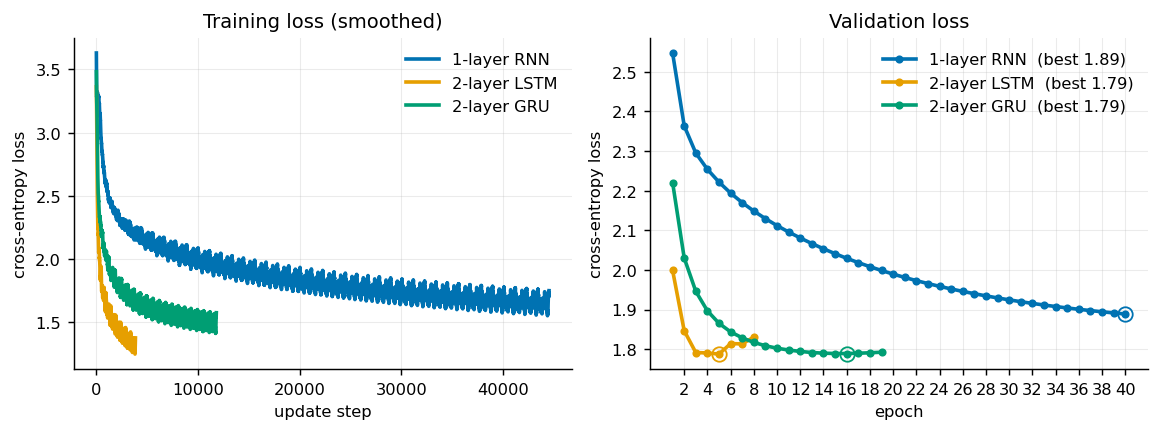

In [2]:
def smooth(values, window=50):
    """Moving average, so the per-batch noise does not hide the trend."""
    if len(values) < window:
        return np.asarray(values)
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3.4))

for name, run in runs.items():
    history = run["history"]
    left.plot(smooth(history["train_loss_steps"]), color=COLORS[name], label=LABELS[name])

    val = history["val_loss_epochs"]
    epochs = np.arange(1, len(val) + 1)
    right.plot(
        epochs,
        val,
        color=COLORS[name],
        marker="o",
        markersize=3.5,
        label=f"{LABELS[name]}  (best {min(val):.2f})",
    )
    # Ring the epoch whose weights were kept.
    right.plot(
        history["best_epoch"],
        min(val),
        marker="o",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=COLORS[name],
    )

last_epoch = max(len(run["history"]["val_loss_epochs"]) for run in runs.values())
left.set(xlabel="update step", ylabel="cross-entropy loss", title="Training loss (smoothed)")
right.set(xlabel="epoch", ylabel="cross-entropy loss", title="Validation loss")
right.set_xticks(np.arange(2, last_epoch + 1, 2))
left.legend(frameon=False)
right.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIGURES / "loss_curves.png", bbox_inches="tight")
plt.show()

The ringed marker is the epoch whose weights were kept: training stops once the
validation loss has not improved for three epochs.

## Model comparison

Test loss is measured on the held-out 15% of the corpus. Perplexity, spelling
accuracy and self-BLEU are measured on the synthesised samples in
`results/<model>/samples.txt`.

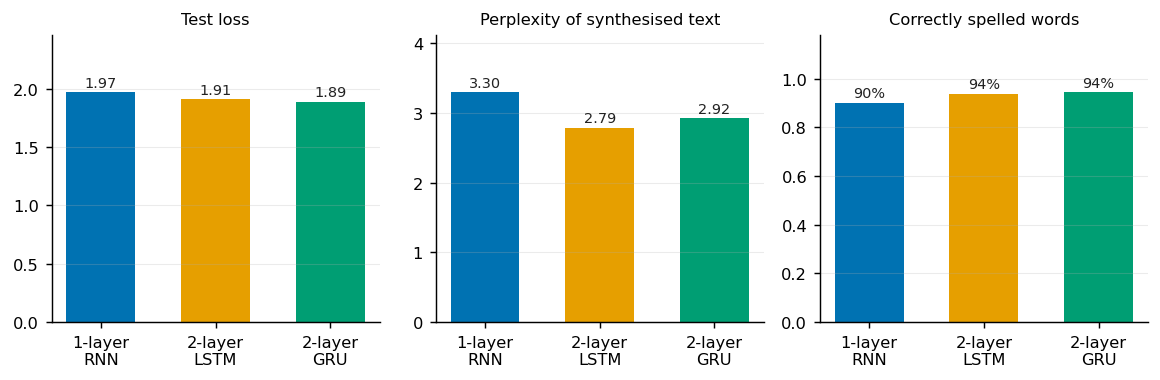

In [3]:
panels = [
    ("test_loss", "Test loss", "{:.2f}"),
    ("perplexity", "Perplexity of synthesised text", "{:.2f}"),
    ("spelling_accuracy", "Correctly spelled words", "{:.0%}"),
]
names = list(runs)

fig, axes = plt.subplots(1, len(panels), figsize=(9, 3.0))
for ax, (key, title, fmt) in zip(axes, panels):
    values = [runs[n]["metrics"][key] for n in names]
    bars = ax.bar(
        [LABELS[n].replace(" ", "\n", 1) for n in names],
        values,
        color=[COLORS[n] for n in names],
        width=0.6,
    )
    # Direct labels: the numbers are the point, so do not make anyone read them off an axis.
    for bar, value in zip(bars, values):
        ax.annotate(
            fmt.format(value),
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="#222222",
        )
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0, max(values) * 1.25)
    ax.grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(FIGURES / "model_comparison.png", bbox_inches="tight")
plt.show()

In [4]:
columns = ["best_epoch", "val_loss", "test_loss", "perplexity", "spelling_accuracy", "self_bleu"]
header = f"{'model':<14}" + "".join(f"{c:>19}" for c in columns)
print(header)
print("-" * len(header))
for name in names:
    metrics = runs[name]["metrics"]
    row = "".join(
        f"{metrics[c]:>19.3f}" if isinstance(metrics[c], float) else f"{metrics[c]:>19}"
        for c in columns
    )
    print(f"{LABELS[name]:<14}{row}")

model                  best_epoch           val_loss          test_loss         perplexity  spelling_accuracy          self_bleu
--------------------------------------------------------------------------------------------------------------------------------
1-layer RNN                    40              1.889              1.970              3.296              0.901              0.034
2-layer LSTM                    5              1.787              1.909              2.785              0.939              0.122
2-layer GRU                    16              1.789              1.890              2.921              0.944              0.049


## Model size and training cost

FLOPs are estimated from the gate matrices and the output projection, counting the
backward pass as twice the forward pass. The wall-clock minutes are what the runs
actually took on an Apple M-series GPU.

In [5]:
from rnn.data import load_text
from rnn.models import CharRNN, parameter_count, training_flops

header = (
    f"{'model':<14}{'parameters':>13}{'update steps':>14}"
    f"{'tokens':>12}{'TFLOPs':>10}{'minutes':>10}{'TFLOPs/min':>12}"
)
print(header)
print("-" * len(header))
for name in names:
    history, metrics = runs[name]["history"], runs[name]["metrics"]
    cfg = history["config"]
    vocab_size = len(set(load_text(Path("..") / cfg["data"], cfg.get("limit_chars"))))
    model = CharRNN(vocab_size, cfg["hidden_size"], cfg["num_layers"], cfg["cell_type"])

    steps = len(history["train_loss_steps"])
    tokens = steps * cfg["batch_size"] * cfg["seq_length"]
    tflops = training_flops(model, tokens) / 1e12
    minutes = metrics["train_minutes"]
    print(
        f"{LABELS[name]:<14}{parameter_count(model):>13,}{steps:>14,}"
        f"{tokens / 1e6:>11.1f}M{tflops:>10.1f}{minutes:>10.1f}{tflops / minutes:>12.1f}"
    )

model            parameters  update steps      tokens    TFLOPs   minutes  TFLOPs/min
-------------------------------------------------------------------------------------
1-layer RNN         134,093        44,600       31.2M      25.0      14.1         1.8
2-layer LSTM      4,177,793         3,896        6.2M     155.9       1.8        85.2
2-layer GRU         228,730        11,856       14.8M      20.2      16.6         1.2


## Synthesised text

In [6]:
for name in names:
    sample = (RESULTS / name / "samples.txt").read_text().split("=" * 70)[0]
    print(f"--- {LABELS[name]} ---\n{sample.strip()[:600]}\n")

--- 1-layer RNN ---
ROMEO: I will not enemies to see her and mine own is the enitizends shall not would, in present and the man of his heart, that the heavenger with the light,
I promise the prince the bear there father sughter sent to thee, shall be good me with parts our part and quite of such a king:
The seep the winders it shall be or ever than my life,
The dreathings that should my speaks, the man a couds and than the dounted to and speak to fight,
I have so wear the cause is the brother and hours of menised and the heaven in the shall reporrous have now they the prince, the peace a glarn's with shall soul h

--- 2-layer LSTM ---
ROMEO: the great of a child: so heavens thing the cut of limits, and by the prince of the received
The matter being son what is the great powers
To say my lord, here he have so approach to she hath been you she does and see her to the since and the officeres,
And the servant: she doing with perpetual heart. Why, there I wish the master,
And the bear of th